# Parameters

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import sys
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterHierarchicalModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.SHAPClassifierModule import *
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]

# Import data

In [3]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

shap.initjs()


## Get Top features

In [4]:
features2remove = [
    "died_in_stay",
    "COVID",
    "charlson_comorbidity_index"
]  # Add the features to remove

In [5]:
helper = ShapHelperClassifier(
    covid_train.drop(columns=["subject_id", "hadm_id"]),
    covid_test.drop(columns=["subject_id", "hadm_id"]),
    "died",
)
helper.removeFeatures(features2remove)

Train size: 2348
Test size: 1007


In [6]:
param = {
    "learning_rate": 0.03194788423314631,
    "n_estimators": 855,
    "gamma": 0.15986032691615765,
    "reg_alpha": 0.7169178389895312,
    "reg_lambda": 0.5826947399857607,
    "scale_pos_weight": 12,
}

Accuracy:  0.7865
Precision: 0.5613
Recall:    0.6877
F1 Score:  0.6181


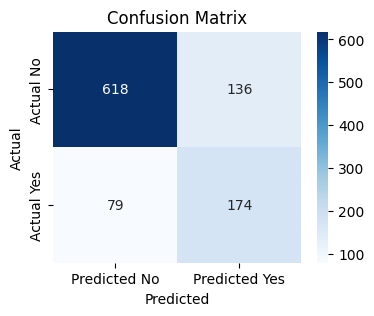

In [7]:
helper.singleModel(param, model_name="xgboost")
helper.printMetrics()
helper.showConfMatrix()

In [8]:
helper.shapConfig()

100%|===================| 1005/1007 [00:18<00:00]       

In [9]:
features = helper.getTopFeatures(20)

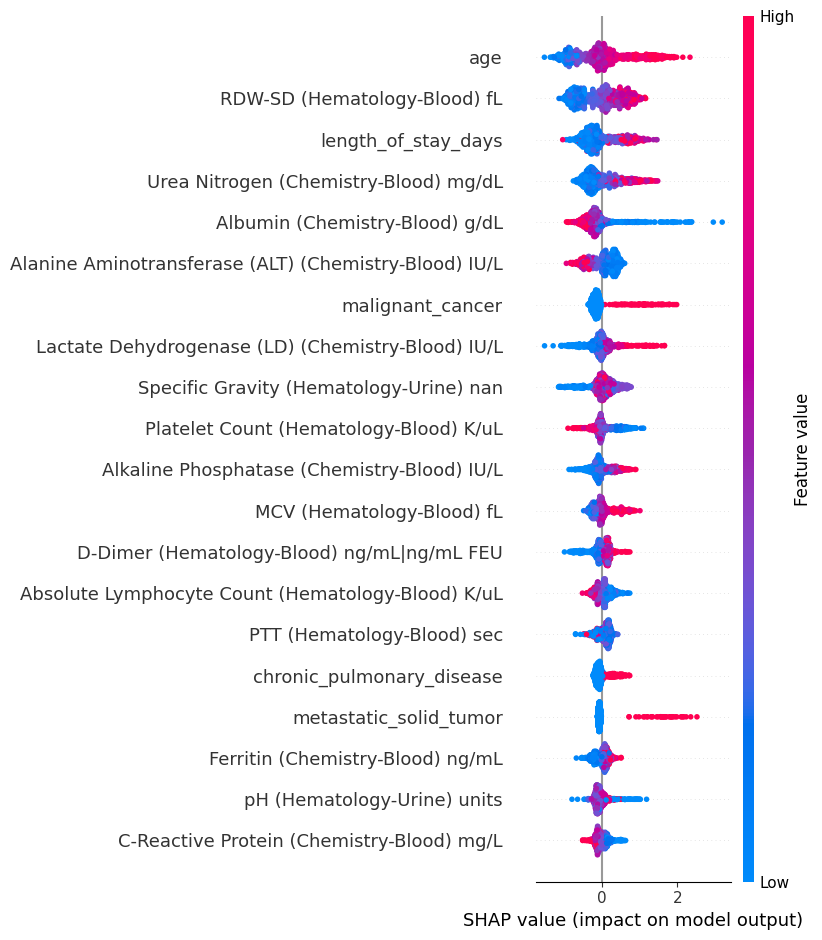

In [10]:
helper.showSummaryShap(verbose=2)

In [11]:
features

['age',
 'RDW-SD_Hematology_Blood_fL',
 'length_of_stay_days',
 'Urea Nitrogen_Chemistry_Blood_mg/dL',
 'Albumin_Chemistry_Blood_g/dL',
 'Alanine Aminotransferase (ALT)_Chemistry_Blood_IU/L',
 'malignant_cancer',
 'Lactate Dehydrogenase (LD)_Chemistry_Blood_IU/L',
 'Specific Gravity_Hematology_Urine_nan',
 'Platelet Count_Hematology_Blood_K/uL',
 'Alkaline Phosphatase_Chemistry_Blood_IU/L',
 'MCV_Hematology_Blood_fL',
 'D-Dimer_Hematology_Blood_ng/mL|ng/mL FEU',
 'Absolute Lymphocyte Count_Hematology_Blood_K/uL',
 'PTT_Hematology_Blood_sec',
 'chronic_pulmonary_disease',
 'metastatic_solid_tumor',
 'Ferritin_Chemistry_Blood_ng/mL',
 'pH_Hematology_Urine_units',
 'C-Reactive Protein_Chemistry_Blood_mg/L']

## Setup Hierarchical Clustering

In [12]:
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [13]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

In [14]:
featuresNotConsidered = [x for x in data_covid.columns.tolist() if x not in features]

In [15]:
helper = cluster.HierarchicalClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered)

## Find best hyperparameters for hierarchical clustering

In [16]:
param_grid = {
    "linkage_methods": ["ward", "complete", "average", "single"],
}

Linkage Methods:   0%|          | 0/4 [00:00<?, ?it/s]

Calculating metrics per k:   0%|          | 0/9 [00:00<?, ?it/s]

Calculating metrics per k:   0%|          | 0/9 [00:00<?, ?it/s]

Calculating metrics per k:   0%|          | 0/9 [00:00<?, ?it/s]

Calculating metrics per k:   0%|          | 0/9 [00:00<?, ?it/s]

""


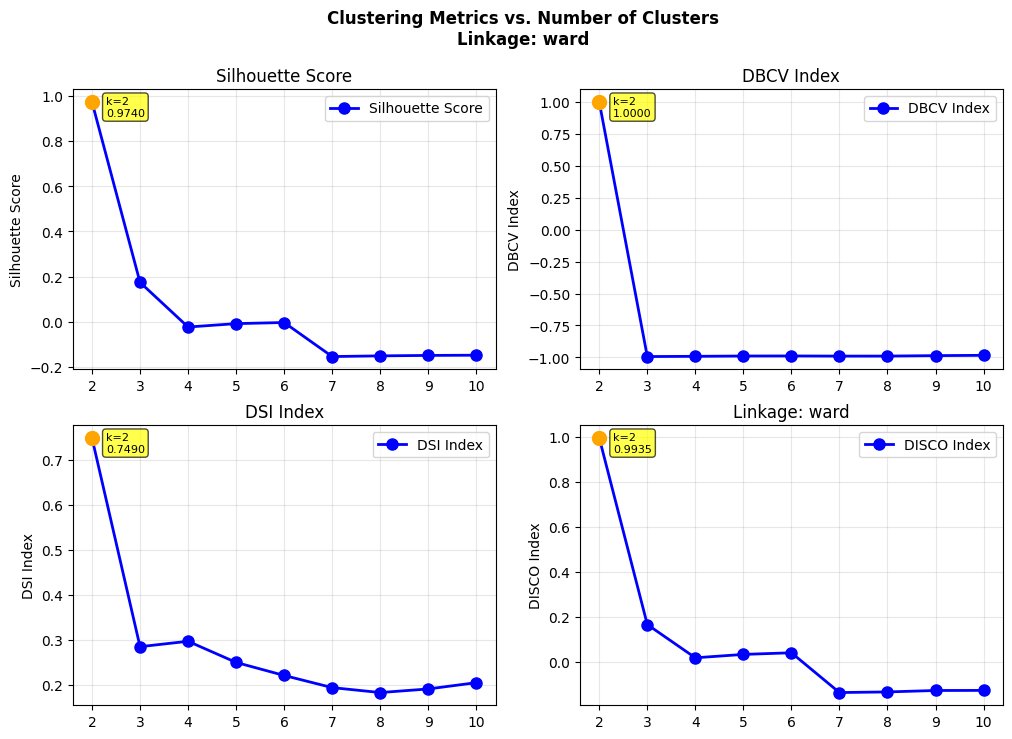

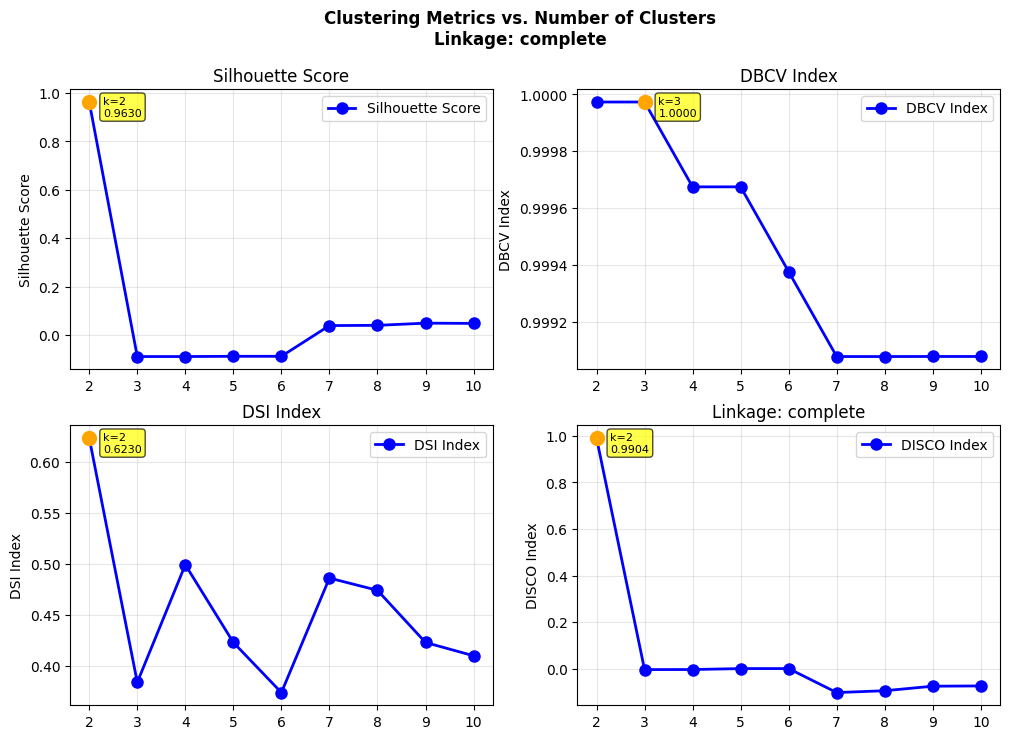

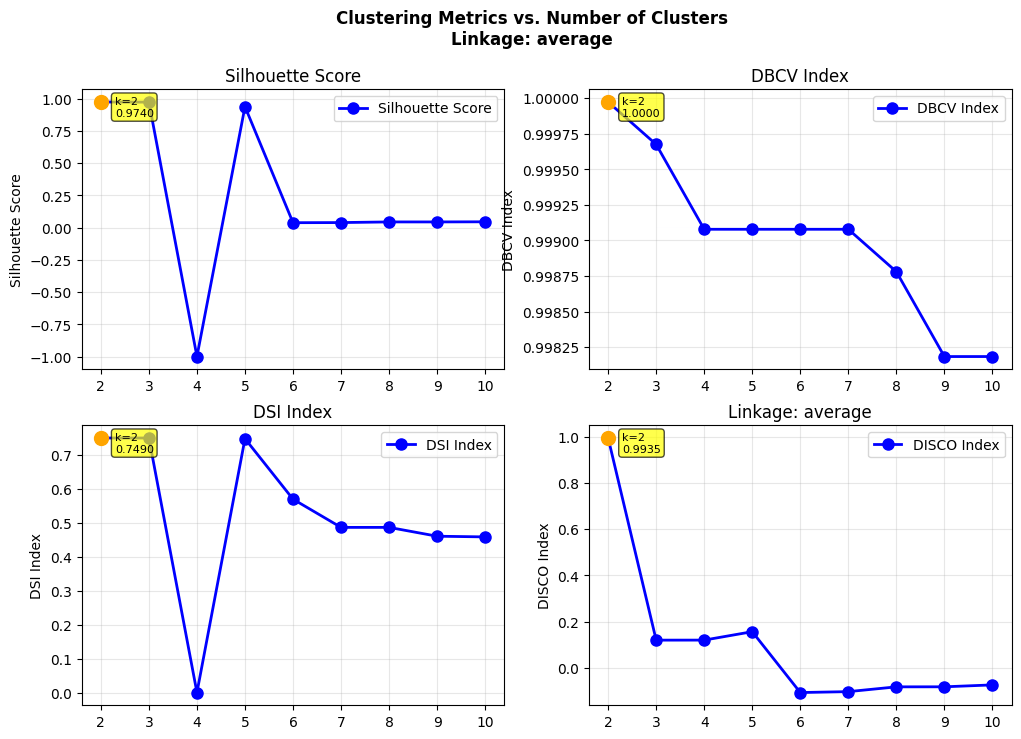

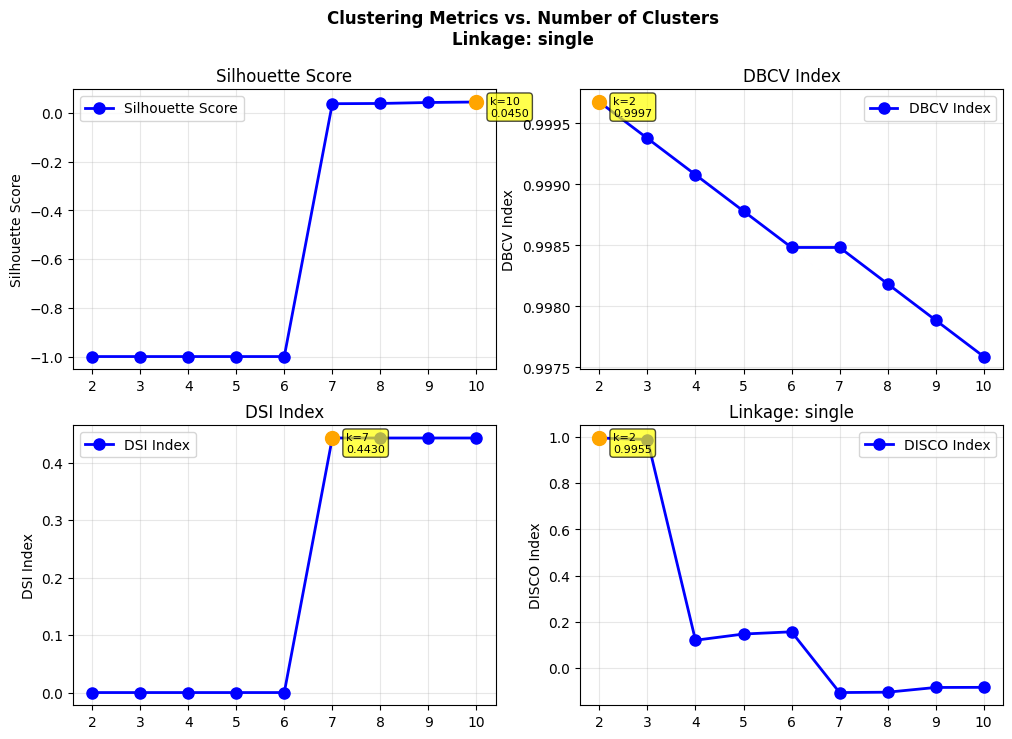

In [17]:
os.environ["PYTHONWARNINGS"] = "ignore"
helper.gridSearchHierarchical(
    param_grid["linkage_methods"],
    figsize=(12,8)
)

## Dendogram

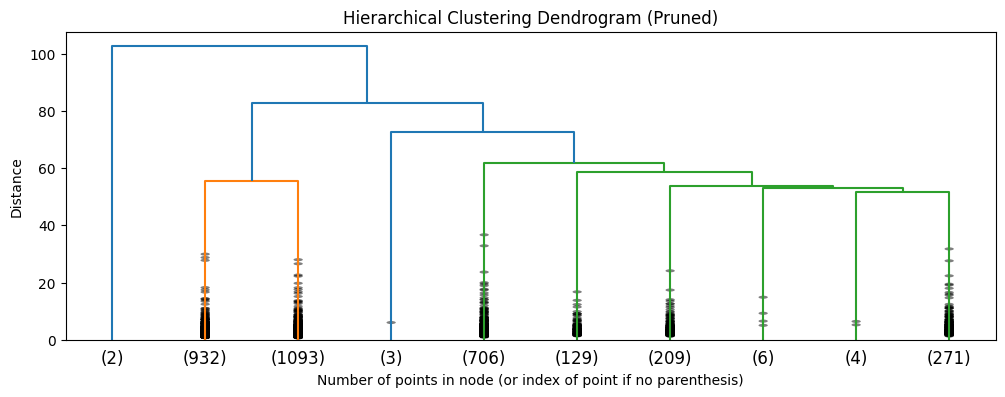

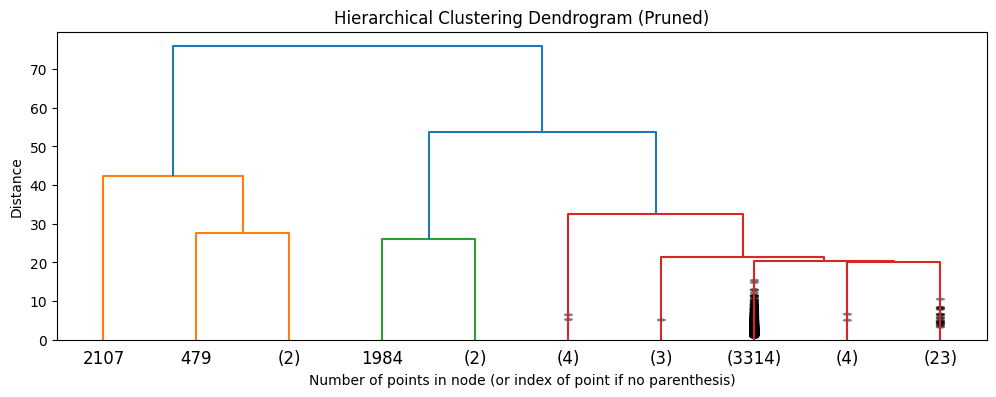

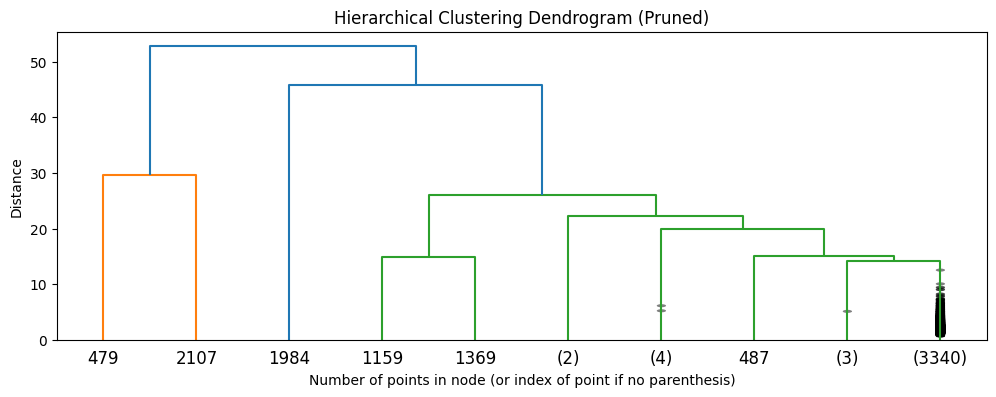

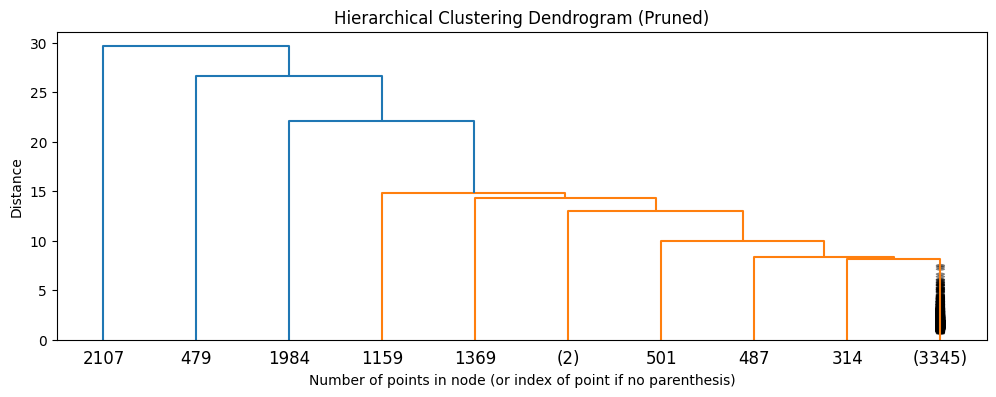

In [18]:
linkage_methods = ["ward", "complete", "average", "single"]

for linkage in linkage_methods:
    helper.plot_dendrogram(
        max_children=10,
        figsize=(12, 4),
        truncate_mode="lastp",
        linkage_method=linkage,
    )


### Complete - Euclidean

#### K = 3

/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:351: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_stats = self.__clusteredData.groupby("Cluster").apply(calculate_stats)
/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:1745: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"n = {occurrence:<4} ({percentages[i]:.2f}%)",


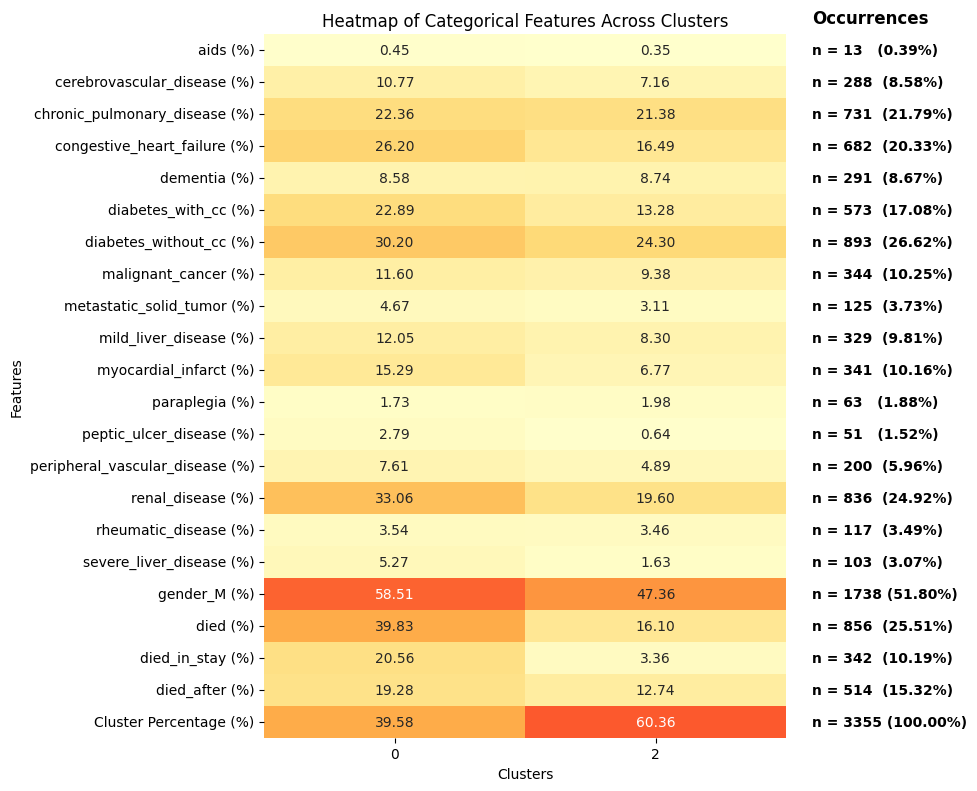

In [ ]:
helper.clustering(n_clusters=3, linkage_method="ward")
helper.heatmapClustersCategorical(figsize=FIGSIZE_CLUSTER_HEATMAP, savepath=IMAGES_SAVE_PATH + "hierarchical-death-categorical")
# helper.showClusteredDataUMAP()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/v

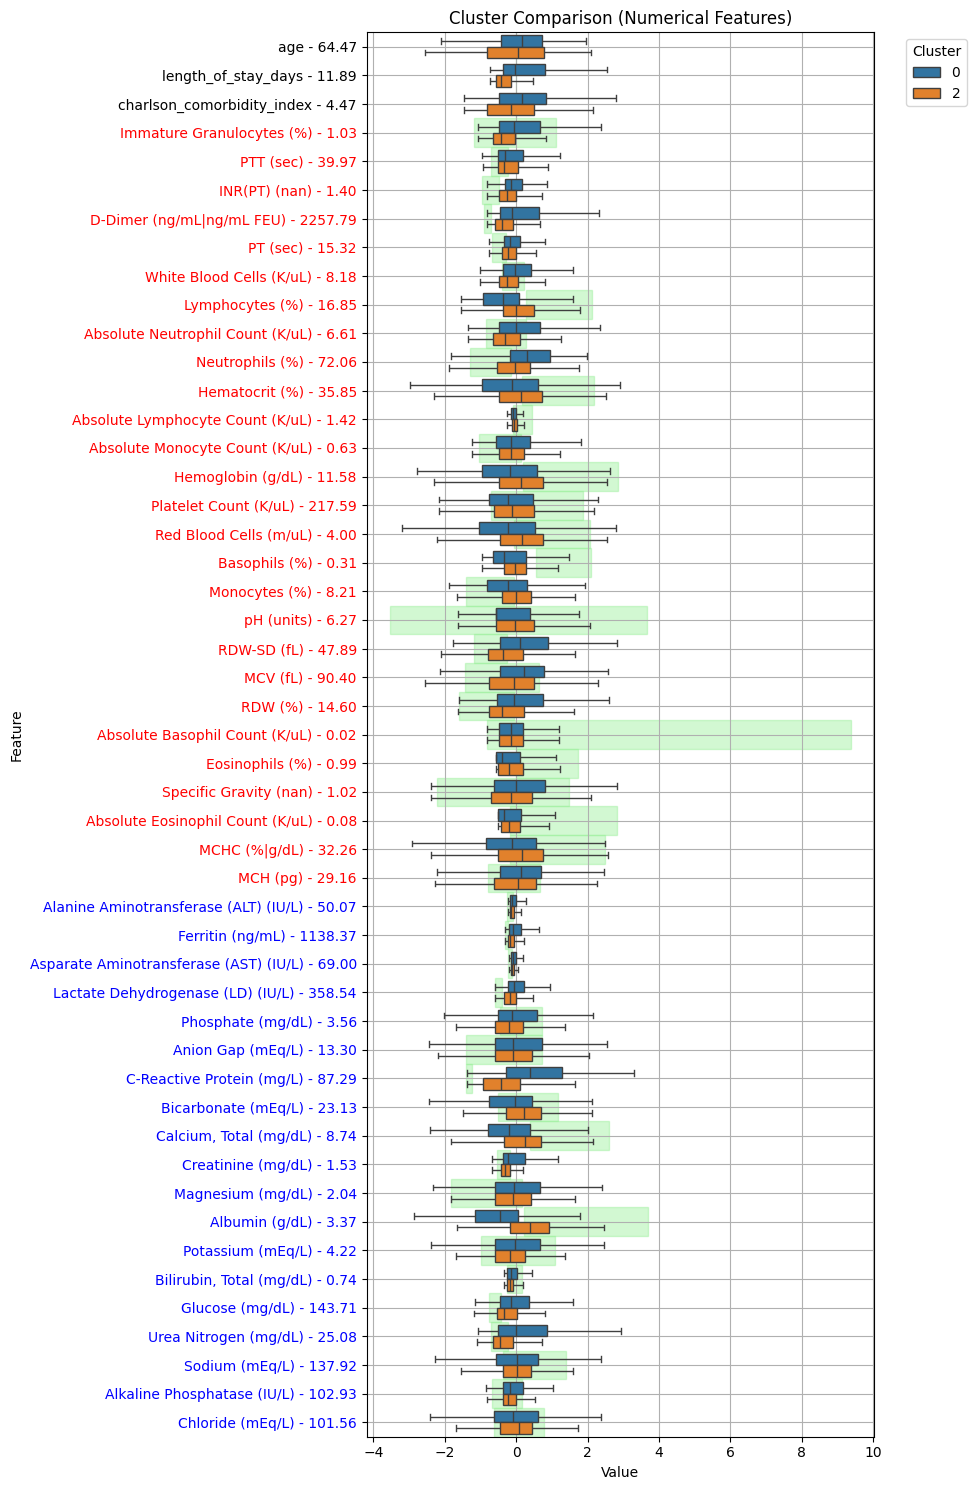

[]

In [ ]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    figsize=(10, 15),
    savepath=IMAGES_SAVE_PATH + "hierarchical-death-numerical", verbose=1)

In [ ]:
selectedClusters = [0, 2]

In [ ]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:24<00:00,  4.11it/s]


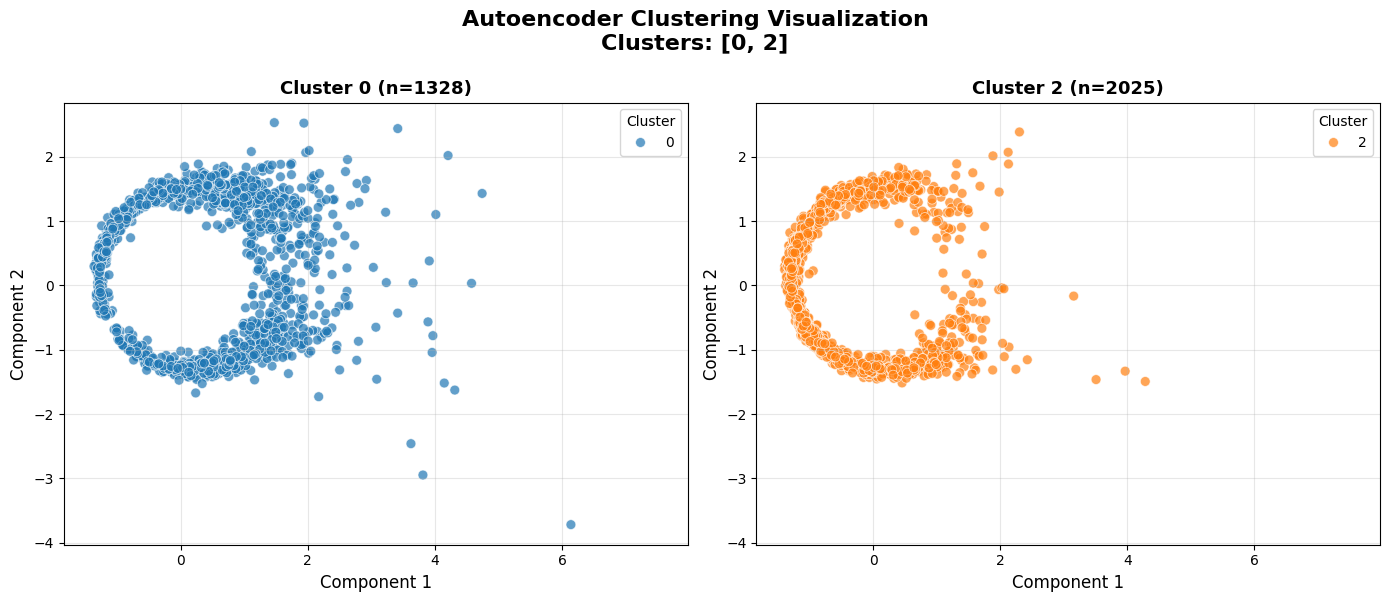

In [ ]:
helper.showClusteredAutoencoder(selectedClusters=selectedClusters, savepath=IMAGES_SAVE_PATH + "hierarchical-autoencoder-death")

##### Future data

/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/FutureAnalysisModule.py:35: UserWarning: Warning: Some subject_ids in futureData are missing from pastData.
  warnings.warn(


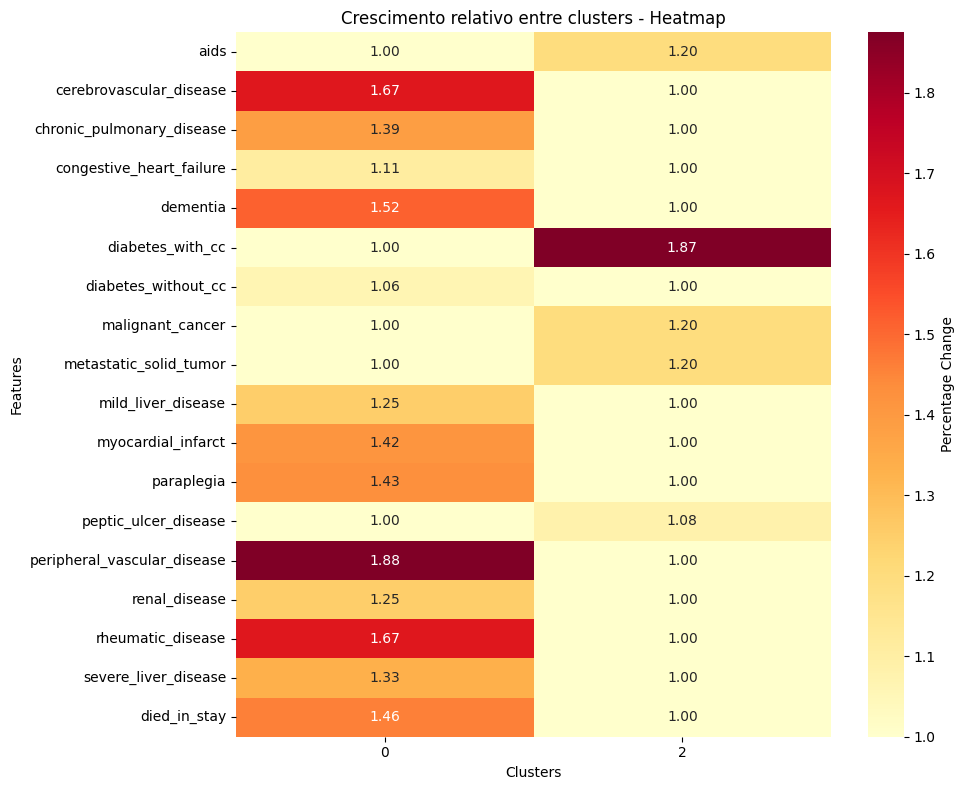

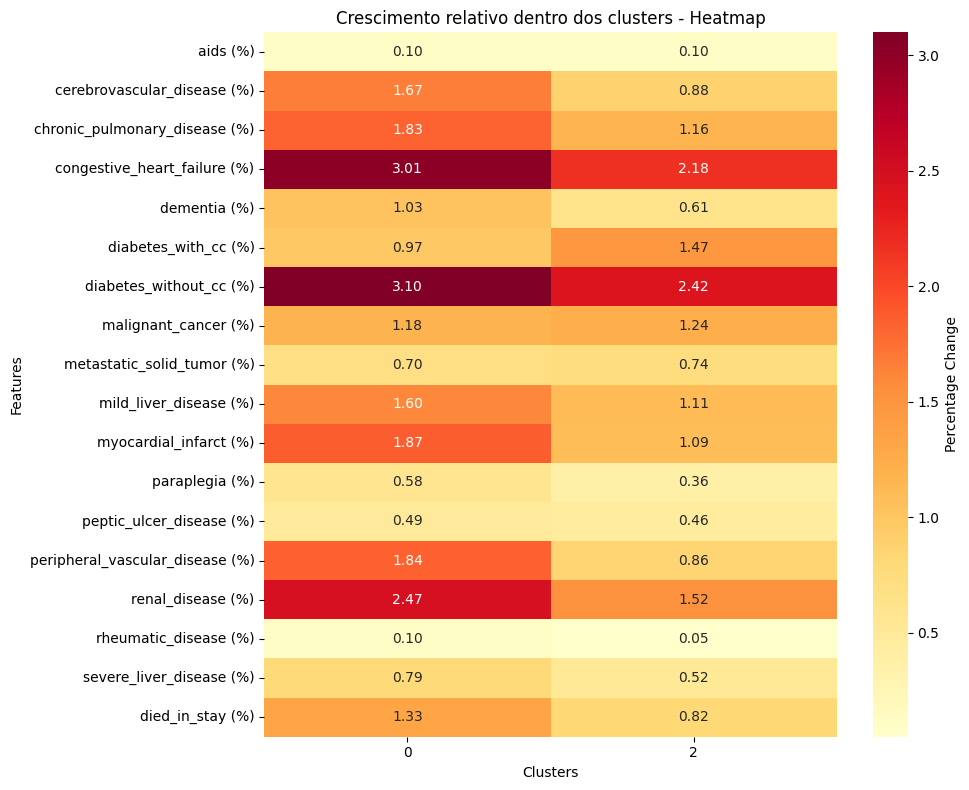

In [ ]:
future_helper = fa.FutureAnalysisHelper(helper.clusteredData, future_data)
future_helper.insertClustersInFutureData(onlyFirstAdmission=True)
delta = future_helper.getDeltaClusters(percentage=True, metric="externo")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "hierarchical-death-externo", selectedClusters=selectedClusters,
    metric="externo"
)
delta = future_helper.getDeltaClusters(percentage=True, metric="interno")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "hierarchical-death-interno", selectedClusters=selectedClusters,
    metric="interno"
)

In [ ]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster 0': 2.45,
 'Mean readmission Cluster 2': 2.23,
 'Overall Mean readmission': 2.31}

In [ ]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster 0': 133.61,
 'Mean days gap Cluster 2': 123.81,
 'Overall Mean days gap': 127.49}

In [ ]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster 0': 0.05,
 'Mortality rate Cluster 2': 0.24,
 'Overall Mortality rate': 0.09}

# Add Log

In [ ]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"Hierarchical, Shap, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
